In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

In [22]:
def canonize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if(mol == None):
        return None
    return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)

def chech_metals(smiles):
    metals = {'Li', 'Be', 'Na', 'Mg', 'Al', 'K', 'Ca', 'Sc', 'Ti', 
              'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ga', 
              'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 
              'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Cs', 'Ba', 'La', 'Ce', 
              'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 
              'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 
              'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'Fr', 
              'Ra', 'Ac', 'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 
              'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr'}

    mol = Chem.MolFromSmiles(smiles)
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol in metals:
            return True
    return False

Loading dataset and convert SMILES string into Mol

In [23]:
df_train = pd.read_csv("dataset/orig/sibur_element_119_final_train_data80.csv")
df_train["Mol"] = [Chem.MolFromSmiles(smiles) for smiles in df_train["SMILES"]]

[23:21:15] SMILES Parse Error: syntax error while parsing: CC(C)MC1=C(C(N=C2NNN=N2)=O)SC(OC)=C1Br
[23:21:15] SMILES Parse Error: check for mistakes around position 6:
[23:21:15] CC(C)MC1=C(C(N=C2NNN=N2)=O)SC(OC)=C1Br
[23:21:15] ~~~~~^
[23:21:15] SMILES Parse Error: Failed parsing SMILES 'CC(C)MC1=C(C(N=C2NNN=N2)=O)SC(OC)=C1Br' for input: 'CC(C)MC1=C(C(N=C2NNN=N2)=O)SC(OC)=C1Br'
[23:21:15] Explicit valence for atom # 8 N, 4, is greater than permitted
[23:21:15] Explicit valence for atom # 9 C, 5, is greater than permitted
[23:21:15] SMILES Parse Error: extra open parentheses while parsing: N(C(N=S)CC
[23:21:15] SMILES Parse Error: check for mistakes around position 2:
[23:21:15] N(C(N=S)CC
[23:21:15] ~^
[23:21:15] SMILES Parse Error: Failed parsing SMILES 'N(C(N=S)CC' for input: 'N(C(N=S)CC'
[23:21:15] SMILES Parse Error: syntax error while parsing: C1=CC2(C3C(CC4(C)CmO)(C(=O)CO)CCC4C3CCC2=CC1=O)=O)C
[23:21:15] SMILES Parse Error: check for mistakes around position 19:
[23:21:15] C1=CC2

Drop incorrect SMILES and SMILES containing metals

In [24]:
df_train_nan = df_train[df_train["Mol"].notna() == False]
df_train_notnan = df_train[df_train["Mol"].notna()]
print(f"Nan values     {df_train_nan.shape[0]}")
print(f"Not nan values {df_train_notnan.shape[0]}")
df_train = df_train.dropna(axis=0)

has_metals = np.array([chech_metals(smiles) for smiles in df_train["SMILES"]])
print(f"Has metal      {has_metals.sum()}")
df_train = df_train[has_metals == False]

Nan values     450
Not nan values 12953
Has metal      2


Different SMILES can describe the same molecules. Convert the SMILES to the same format and calculate the average for the same SMILES.

In [25]:
df_train["SMILES"] = [ canonize(smiles) for smiles in df_train["SMILES"] ]
df_train = df_train[["SMILES","LogP"]]

aggregations = {
    "SMILES": "first",
    "LogP": "mean"
}
df_train = df_train.groupby(['SMILES'], as_index=False).agg(aggregations)
df_train["Mol"] = [Chem.AddHs(Chem.MolFromSmiles(smiles)) for smiles in df_train["SMILES"]]
df_train

,SMILES,LogP,Mol
0,BrC(Br)(Br)Br,4.147,<rdkit.Chem.rdchem.Mol object at 0x00000151814...
1,BrC1C2CC3C(C2)C13,4.168,<rdkit.Chem.rdchem.Mol object at 0x00000151814...
2,BrC1CC2CCC1C2,4.308,<rdkit.Chem.rdchem.Mol object at 0x00000151814...
3,BrC1CCCCC1,4.719,<rdkit.Chem.rdchem.Mol object at 0x00000151814...
4,BrCC(CBr)(CBr)CBr,5.535,<rdkit.Chem.rdchem.Mol object at 0x00000151814...
...,...,...,...
10877,c1ncncn1,0.650,<rdkit.Chem.rdchem.Mol object at 0x00000151819...
10878,c1nn[nH]n1,0.483,<rdkit.Chem.rdchem.Mol object at 0x00000151819...
10879,c1nnn(C23CC4CC(CC(C4)C2)C3)n1,3.755,<rdkit.Chem.rdchem.Mol object at 0x00000151819...
10880,c1nnnn1C12CC3CC(CC(C3)C1)C2,4.398,<rdkit.Chem.rdchem.Mol object at 0x00000151819...


Calculate physical and chemical descriptors using SMILES and rdkit

In [26]:
descriptors = [ Descriptors.CalcMolDescriptors(mol) for mol in df_train["Mol"] ]
    
descriptors_df = pd.DataFrame(descriptors)
df_train = pd.concat([descriptors_df, df_train["LogP"], df_train["SMILES"]],axis = 1)
df_train = df_train.dropna(axis=0)    

Based on chemical considerations, values less than -5 and greater than 10 are unlikely.

Dropped count: 80


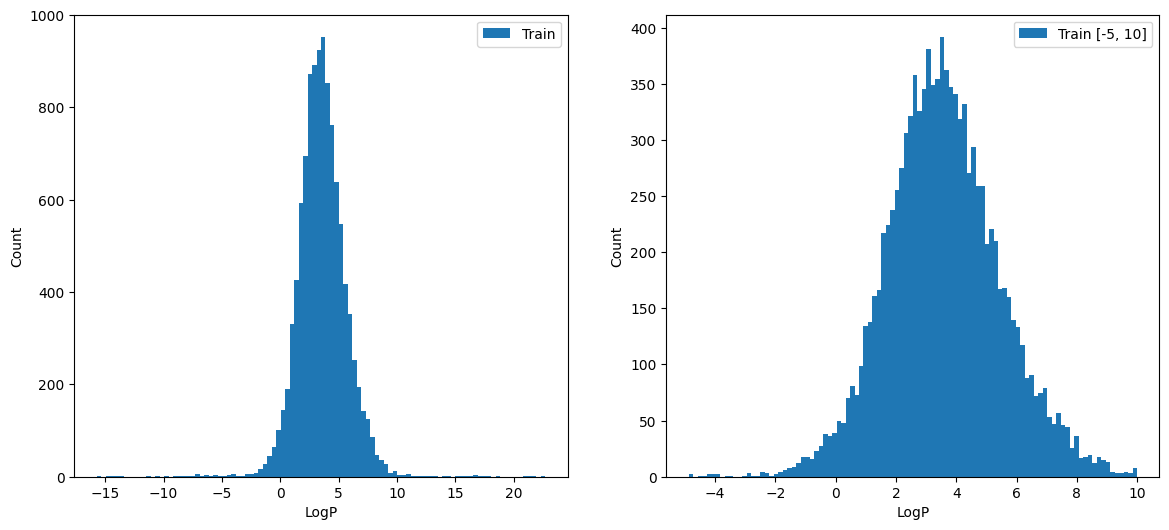

In [27]:
df_train_old = df_train.copy()
df_train = df_train[(-5 < df_train["LogP"]) & (df_train["LogP"] < 10)]
fig, axe = plt.subplots(1,2, figsize=(2*7,6))

axe[0].hist(df_train_old["LogP"], bins = 100 , label = "Train")
axe[1].hist(df_train["LogP"], bins = 100, label = "Train [-5, 10]")
axe[0].set_xlabel("LogP")
axe[0].set_ylabel("Count")
axe[1].set_xlabel("LogP")
axe[1].set_ylabel("Count")
axe[1].legend()
axe[0].legend()
print(f"Dropped count: {df_train_old.shape[0]-df_train.shape[0]}")

Drop equal descriptors, descriptors with an insufficient number of values. Normalize Ipc and Kappa3 Descriptors using log function

In [28]:
equal_columns = [ "MaxAbsEStateIndex", "MolWt" ]
zero_columns  = [ "SMR_VSA8", "SlogP_VSA9", "fr_diazo","fr_dihydropyridine", "fr_isocyan", "fr_phos_ester", "fr_prisulfonamd"]
one_columns = ["NumRadicalElectrons"]
df_train = df_train.drop(labels=equal_columns,axis=1)
df_train = df_train.drop(labels=zero_columns,axis=1)
df_train = df_train.drop(labels=one_columns,axis=1)
df_train["LogIpc"] = np.log(df_train["Ipc"])
df_train["LogKappa3"] = np.log(df_train["Kappa3"])
df_train["LogKappa3"] = df_train["LogKappa3"].replace(-np.inf,np.median(df_train["LogKappa3"]))
df_train = df_train.drop(labels=["Ipc","Kappa3"],axis=1)

c:\Users\Ivan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


PCA shows the points that are out of the general distribution. Isolation Forest defines them as outliers

Outliers count: 338


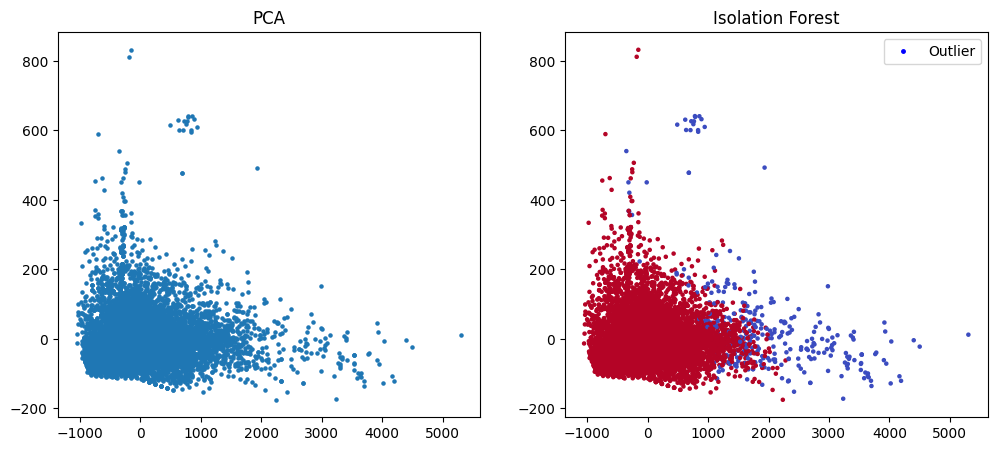

In [ ]:
iforest_x = df_train.drop(labels=["LogP","SMILES"],axis=1)
IForest = IsolationForest(
    n_estimators=1000,
    contamination='auto',
    random_state=42
)
iforest_outliers = IForest.fit_predict(iforest_x)
iforest_data = pd.DataFrame(PCA(n_components=2).fit_transform(iforest_x))
iforest_data["Outlier"] = iforest_outliers

fig, axe = plt.subplots(1,2,figsize=(6*2, 5))
axe[0].scatter(iforest_data.iloc[:,0], iforest_data.iloc[:,1], s=5)
axe[0].set_title(f"PCA")

axe[1].scatter(iforest_data.iloc[:,0], iforest_data.iloc[:,1], c=iforest_data["Outlier"], cmap="coolwarm", s=5)
axe[1].legend(handles=[mlines.Line2D([], [],ls = "None", color="blue",marker=".",  markersize=5, label="Outlier")])
axe[1].set_title(f"Isolation Forest")
df_train = df_train[iforest_outliers == 1]
print(f"Outliers count: {sum(iforest_data["Outlier"]==-1)}")

Drop Isolation Forest outliers. Drop non physical features

In [30]:
df_train = df_train[iforest_outliers == 1]
selected_features = []

for col in df_train.columns:
    if(("fr_" in col) == False):
        selected_features.append(col)
    
df_train = df_train[selected_features]
df_train

,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,MinPartialCharge,...,NumSpiroAtoms,NumUnspecifiedAtomStereoCenters,Phi,RingCount,MolLogP,MolMR,LogP,SMILES,LogIpc,LogKappa3
0,3.125000,0.250000,-0.250000,0.598169,12.000000,331.627,327.673348,32,0.188533,-0.047133,...,0,0,3.161824,0,3.1773,38.4390,4.147,BrC(Br)(Br)Br,1.283608,3.205869
1,8.031250,2.276042,-2.723958,0.491423,148.875000,163.981,171.988762,44,0.042898,-0.088441,...,0,3,0.160657,4,2.0357,35.9090,4.168,BrC1C2CC3C(C2)C13,8.352590,-1.281849
2,8.031250,2.552708,-3.256875,0.496072,125.875000,163.981,174.004412,46,0.042596,-0.088756,...,0,3,0.244411,2,2.5699,38.1630,4.308,BrC1CC2CCC1C2,8.703896,-0.451184
3,7.639583,2.408333,-3.439167,0.481348,89.000000,151.970,162.004412,42,0.042295,-0.089069,...,0,0,0.355545,1,2.7140,35.8000,4.719,BrC1CCCCC1,7.930850,0.592546
4,7.577292,2.532917,-2.750000,0.647209,31.555556,379.671,383.735949,56,0.039326,-0.092109,...,0,0,2.065458,0,3.5524,57.6090,5.535,BrCC(CBr)(CBr)CBr,6.751585,1.166682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10877,6.774444,0.333333,-0.333333,0.436398,15.000000,78.054,81.032697,30,0.118516,-0.224904,...,0,0,0.302909,1,-0.1284,19.8270,0.650,c1ncncn1,4.451517,-0.724662
10878,6.590278,0.226852,-0.226852,0.434429,13.600000,68.039,70.027946,26,0.216156,-0.177479,...,0,0,0.165354,1,-0.8003,14.1777,0.483,c1nn[nH]n1,3.843112,-1.550291
10879,8.680580,0.078449,-3.921700,0.697520,97.866667,188.149,204.137497,80,0.161577,-0.158247,...,0,0,0.380714,5,1.5984,53.9630,3.755,c1nnn(C23CC4CC(CC(C4)C2)C3)n1,14.676042,0.048087
10880,8.690406,0.039097,-3.933750,0.697520,97.866667,188.149,204.137497,80,0.138287,-0.226384,...,0,0,0.380714,5,1.5984,53.9630,4.398,c1nnnn1C12CC3CC(CC(C3)C1)C2,14.700204,0.048087


Do equal transformation for test data and datasets

In [31]:
df_test = pd.read_csv("dataset/orig/sibur_element_119_final_test_data80.csv")
df_test["SMILES"] = [ canonize(smiles) for smiles in df_test["SMILES"] ]
df_test["Mol"] = [Chem.AddHs(Chem.MolFromSmiles(smiles)) for smiles in df_test["SMILES"]]

descriptors = [ Descriptors.CalcMolDescriptors(mol) for mol in df_test["Mol"] ]
descriptors_df = pd.DataFrame(descriptors)
df_test = pd.concat([descriptors_df,  df_test["SMILES"]],axis = 1)
df_test = df_test.dropna(axis=0) 

equal_columns = [ "MaxAbsEStateIndex", "MolWt" ]
zero_columns  = [ "SMR_VSA8", "SlogP_VSA9", "fr_diazo","fr_dihydropyridine", "fr_isocyan", "fr_phos_ester", "fr_prisulfonamd"]
one_columns = ["NumRadicalElectrons"]
df_test = df_test.drop(labels=equal_columns,axis=1)
df_test = df_test.drop(labels=zero_columns,axis=1)
df_test = df_test.drop(labels=one_columns,axis=1)
df_test["LogIpc"] = np.log(df_test["Ipc"])
df_test["LogKappa3"] = np.log(df_test["Kappa3"])
df_test["LogKappa3"] = df_test["LogKappa3"].replace(-np.inf,np.median(df_test["LogKappa3"]))
df_test = df_test.drop(labels=["Ipc","Kappa3"],axis=1)

In [32]:
df_train.to_csv("train_data.csv", index=False)
df_test.to_csv("test_data.csv", index=False)